<a href="https://colab.research.google.com/github/lokendrasinghofficial/20Class-Image-Classification/blob/main/College%20Earnings%20Prediction%20using%20Multiple%20Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**College Earnings & Cost (Simplified Version)**

This dataset is a cleaned and simplified version of the U.S. College Scorecard data, designed for undergraduate analysis. It includes key variables that allow students to examine the relationship between education and financial outcomes using Multiple Linear Regression.

Each observation represents a university, with the following variables:

- School: Name of the institution
- Earnings: Median earnings of former students (after graduation)
- Cost: Average cost of attendance
- Debt: Median student loan debt
- Grad: Graduation rate
- City_Rural, City_Suburb, City_Town: Dummy variables representing the institution’s location type (with City as the baseline category)

**This dataset is intentionally preprocessed to:**

Remove missing and inconsistent values

Simplify variable structure

Allow direct application of regression techniques without extensive data cleaning

Students will use this dataset to build, interpret, and evaluate a Multiple Linear Regression model,
focusing on how cost, debt, graduation rate, and location influence post-college earnings.

In [3]:
import pandas as pd

# Load data
df = pd.read_csv(
    "Most-Recent-Cohorts-Scorecard-Elements.csv",
    encoding="latin1",
    low_memory=False
)

# Create unified Cost variable
df["Cost"] = df["NPT4_PUB"].fillna(df["NPT4_PRIV"])

# Select relevant columns
df_selected = df[[
    "INSTNM",                  # School
    "MD_EARN_WNE_P10",         # Earnings
    "Cost",                    # Cost
    "GRAD_DEBT_MDN_SUPP",      # Debt
    "C150_4_POOLED_SUPP",      # Graduation rate
    "LOCALE"                   # Location
]]

# Rename for clarity (recommended for students)
df_selected.columns = [
    "School",
    "Earnings",
    "Cost",
    "Debt",
    "Grad",
    "City"
]

# Handle 'PrivacySuppressed' values
df_selected = df_selected.replace("PrivacySuppressed", pd.NA)

# Convert numeric columns
for col in ["Earnings", "Cost", "Debt", "Grad"]:
    df_selected[col] = pd.to_numeric(df_selected[col], errors="coerce")

# Drop missing values
df_selected = df_selected.dropna()

# Preview
df_selected.head()

,School,Earnings,Cost,Debt,Grad,City
0,Alabama A & M University,30300.0,15229.0,33888.0,0.324520,12.0
1,University of Alabama at Birmingham,39700.0,14789.0,21941.5,0.546105,12.0
3,University of Alabama in Huntsville,45500.0,18596.0,24097.0,0.472406,12.0
4,Alabama State University,26600.0,11110.0,33118.5,0.257405,12.0
5,The University of Alabama,41900.0,20787.0,23750.0,0.661251,13.0


In [4]:
#The Value Counts in the feature "City"
df_selected.value_counts("City")

,count
City,
11.0,477
21.0,471
13.0,315
12.0,260
32.0,189
33.0,122
41.0,67
22.0,61
31.0,59


| Code | Description     |
| ---- | --------------- |
| 11   | City: Large     |
| 12   | City: Midsize   |
| 13   | City: Small     |
| 21   | Suburb: Large   |
| 22   | Suburb: Midsize |
| 23   | Suburb: Small   |
| 31   | Town: Fringe    |
| 32   | Town: Distant   |
| 33   | Town: Remote    |
| 41   | Rural: Fringe   |
| 42   | Rural: Distant  |
| 43   | Rural: Remote   |


**The variable LOCALE (your “City”) comes from the NCES urbanicity classification, which encodes how urban or rural a school’s location is.**

In [5]:
#Simplify into 4 interpretable groups
def map_locale(x):
    if x in [11, 12, 13]:
        return "City"
    elif x in [21, 22, 23]:
        return "Suburb"
    elif x in [31, 32, 33]:
        return "Town"
    elif x in [41, 42, 43]:
        return "Rural"

df_selected["City"] = df_selected["City"].apply(map_locale)

In [6]:
#Full Dummy Encoding
df_selected = pd.get_dummies(df_selected, columns=["City"], drop_first=True)

In [23]:
#Selected dataset to begin the Regression Analysis
df_selected.head(10)

,School,Earnings,Cost,Debt,Grad,City_Rural,City_Suburb,City_Town
0,Alabama A & M University,30300.0,15229.0,33888.0,0.324520,False,False,False
1,University of Alabama at Birmingham,39700.0,14789.0,21941.5,0.546105,False,False,False
3,University of Alabama in Huntsville,45500.0,18596.0,24097.0,0.472406,False,False,False
4,Alabama State University,26600.0,11110.0,33118.5,0.257405,False,False,False
5,The University of Alabama,41900.0,20787.0,23750.0,0.661251,False,False,False
8,Auburn University at Montgomery,35000.0,13431.0,21335.0,0.241364,False,False,False
9,Auburn University,45700.0,18644.0,21831.0,0.693542,False,False,False
10,Birmingham Southern College,44200.0,18728.0,27000.0,0.630713,False,False,False
13,South University-Montgomery,28800.0,23048.0,25167.0,0.085079,False,False,False
16,Faulkner University,37200.0,20240.0,22000.0,0.262232,False,False,False


**EDA Exploratory Data Analysis**

In [15]:
#importing the required Libraries for Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df_selected.info()
df_selected.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 2110 entries, 0 to 6959
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   School       2110 non-null   object 
 1   Earnings     2110 non-null   float64
 2   Cost         2110 non-null   float64
 3   Debt         2110 non-null   float64
 4   Grad         2110 non-null   float64
 5   City_Rural   2110 non-null   bool   
 6   City_Suburb  2110 non-null   bool   
 7   City_Town    2110 non-null   bool   
dtypes: bool(3), float64(4), object(1)
memory usage: 105.1+ KB


,Earnings,Cost,Debt,Grad
count,2110.000000,2110.000000,2110.000000,2110.000000
mean,39364.881517,19312.576303,23359.389810,0.490049
std,10808.172797,7116.768531,5989.451581,0.193634
min,12100.000000,2280.000000,2525.000000,0.022549
25%,32525.000000,14336.250000,20751.500000,0.348291
50%,38800.000000,19003.000000,24903.000000,0.473651
75%,44700.000000,23853.750000,27000.000000,0.622719
max,118800.000000,46509.000000,49750.000000,0.974950


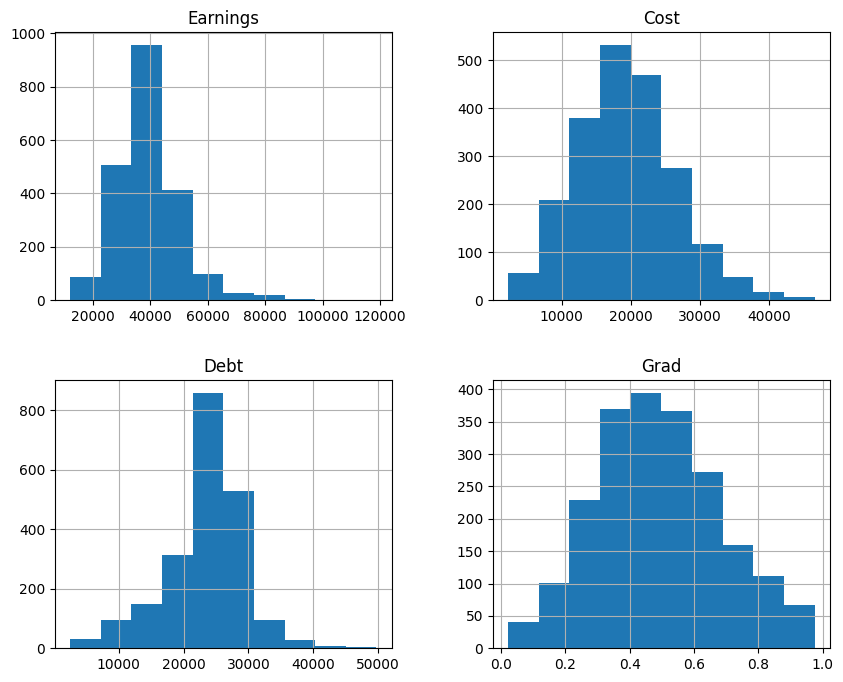

In [17]:
#This is the Distribution Plots , how the data is distributed
df_selected[["Earnings", "Cost", "Debt", "Grad"]].hist(figsize=(10,8))
plt.show()


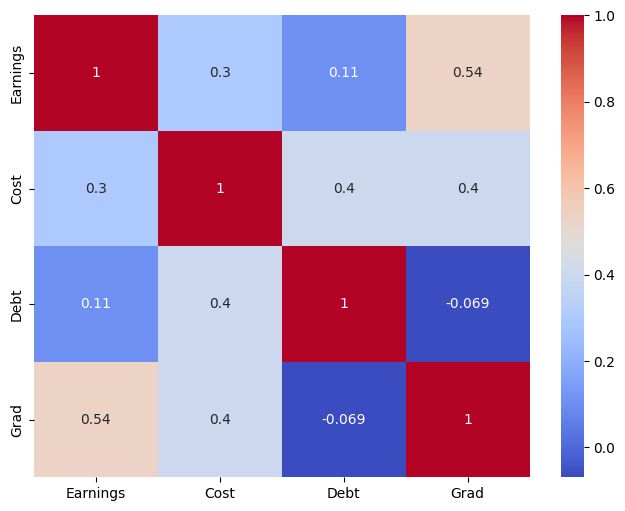

In [24]:
#This is the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_selected[["Earnings","Cost","Debt","Grad"]].corr(),
            annot=True, cmap="coolwarm")
plt.show()


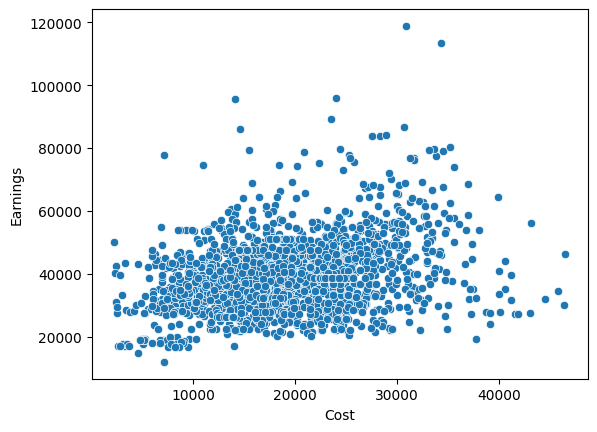

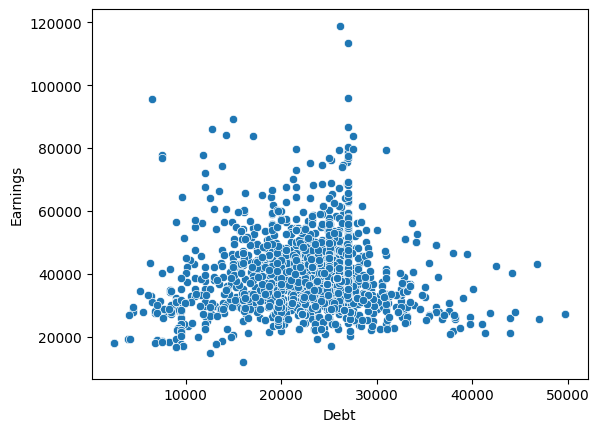

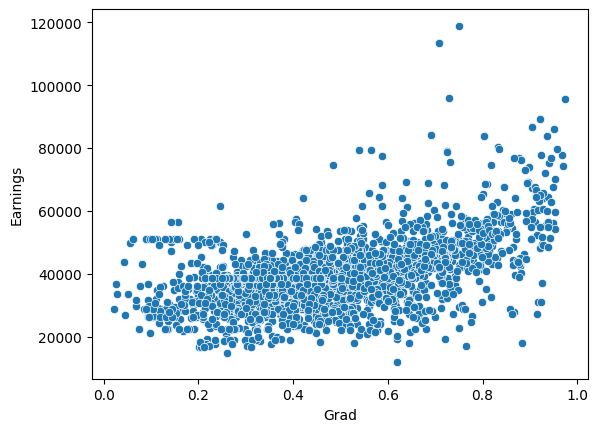

In [19]:
#This is the scatterplot representing on Y axis as Earning vs Cost ,Debt,Grad on the X axis
sns.scatterplot(x="Cost", y="Earnings", data=df_selected)
plt.show()

sns.scatterplot(x="Debt", y="Earnings", data=df_selected)
plt.show()

sns.scatterplot(x="Grad", y="Earnings", data=df_selected)
plt.show()

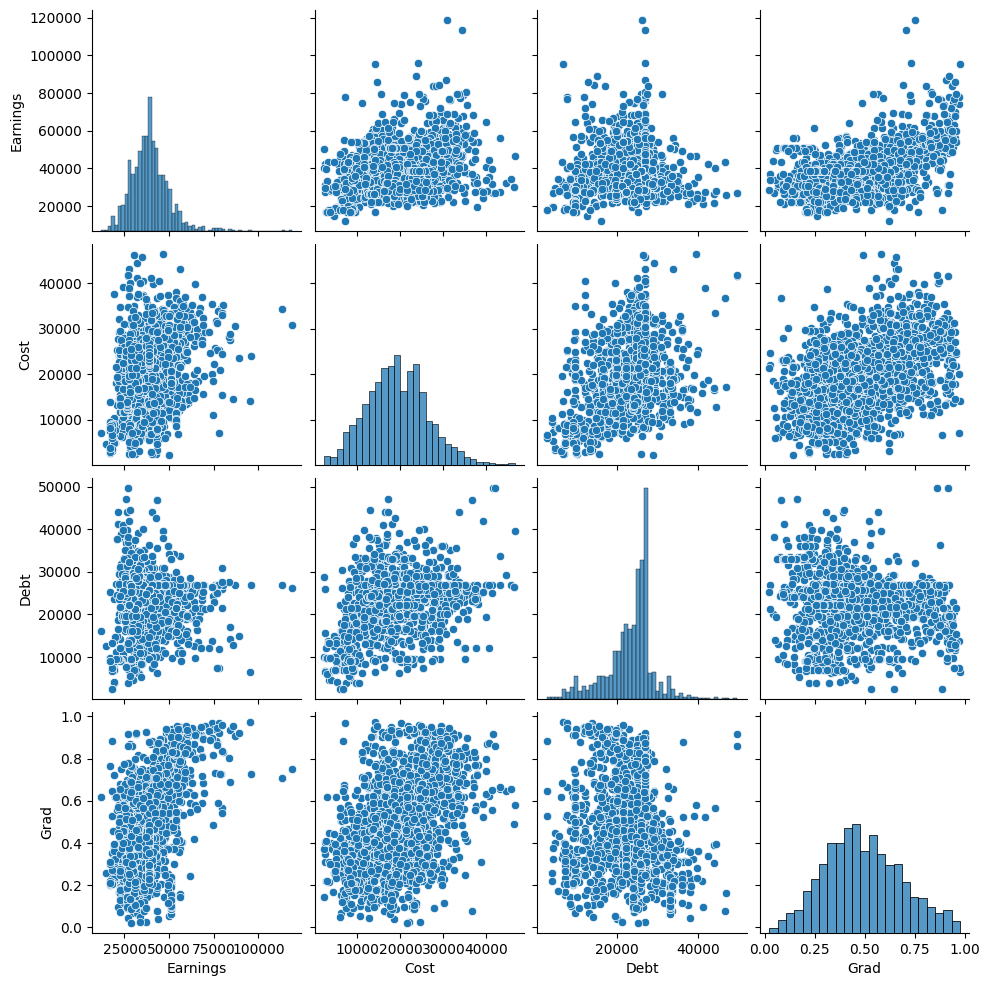

In [21]:
#Pairplot representing the scatter plot of every column
sns.pairplot(df_selected[["Earnings","Cost","Debt","Grad"]])
plt.show()

In [8]:
#import statsmodels.api as sm
#Here i  want to build a regression model to predict Earnings by using the formula Earnings=β0​+β1​Cost+β2​Debt+β3​Grad
# Define X (independent variables) and y (dependent)
X = df_selected[["Cost", "Debt", "Grad"]]
y = df_selected["Earnings"]

# Add constant (β0)
X = sm.add_constant(X)

# Fit model
model1 = sm.OLS(y, X).fit()

# Summary
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:               Earnings   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     312.5
Date:                Thu, 09 Apr 2026   Prob (F-statistic):          8.38e-168
Time:                        01:58:37   Log-Likelihood:                -22203.
No. Observations:                2110   AIC:                         4.441e+04
Df Residuals:                    2106   BIC:                         4.444e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.841e+04    961.665     19.149      0.0

In [10]:
#Predictions
# Example prediction
sample = pd.DataFrame({
    "const": [1],
    "Cost": [25000],
    "Debt": [80],
    "Grad": [60]
})

prediction = model1.predict(sample)
print("Predicted Earnings:", prediction.values[0])

Predicted Earnings: 1793595.5649408444


In [12]:
#Adding City Dummies Models

# New X with dummies
X2 = df_selected[["Cost", "Debt", "Grad", "City_Rural", "City_Suburb", "City_Town"]]
y2 = df_selected["Earnings"]

# Convert boolean dummy variables to integers
X2["City_Rural"] = X2["City_Rural"].astype(int)
X2["City_Suburb"] = X2["City_Suburb"].astype(int)
X2["City_Town"] = X2["City_Town"].astype(int)

# Add constant
X2 = sm.add_constant(X2)

# Fit model
model2 = sm.OLS(y2, X2).fit()

# Summary
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:               Earnings   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     158.8
Date:                Thu, 09 Apr 2026   Prob (F-statistic):          1.13e-166
Time:                        02:02:11   Log-Likelihood:                -22197.
No. Observations:                2110   AIC:                         4.441e+04
Df Residuals:                    2103   BIC:                         4.445e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.894e+04    986.973     19.193      

/tmp/ipykernel_913/2986063688.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X2["City_Rural"] = X2["City_Rural"].astype(int)
/tmp/ipykernel_913/2986063688.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X2["City_Suburb"] = X2["City_Suburb"].astype(int)
/tmp/ipykernel_913/2986063688.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

In [13]:
print("Model 1 R-squared:", model1.rsquared)
print("Model 2 R-squared:", model2.rsquared)

Model 1 R-squared: 0.30802591483989805
Model 2 R-squared: 0.311856764677621


#“R² increased after adding city dummies, indicating that location improving the  explanatory power.”


  Model 1 (Without City) R² = 0.308

  Model 2 (With City)   R² = 0.3118

 So:

> Model 2 is better

---

#  1. Model performed better?


> The model including city dummy variables performed better because it has a higher R-squared value (0.3118 vs 0.308), indicating improved explanatory power.

---

#  2. Adding more variables help?


> Yes, adding city dummy variables slightly improved the model’s performance, suggesting that location has some impact on earnings.


---

#  3. What did we predict?

> The model predicts post-college earnings of students based on cost, debt, graduation rate, and location.

---

#  4. Interpretation of coefficients

###  From Model 1:

* **Cost (β₁ ≈ 0.056)**
   Small positive effect
   But **p-value = 0.097 → not very significant**

* **Debt (β₂ ≈ 0.23)**
   Higher debt → higher earnings
   (maybe better colleges → higher salary)

* **Grad (β₃ ≈ 29560)**
   VERY strong positive effect
   Most important variable

---

###  From Model 2 (when the City included):

* **City_Rural (≈ -1334)**
   Rural colleges earn LESS than city

* **City_Suburb (≈ -7)**
   Almost no difference

* **City_Town (≈ -1700)**
   Town colleges earn LESS than city

 So overall:

> City colleges give slightly higher earnings



#  5. Prediction Interpretation

```
Predicted Earnings ≈ 179,395
```


> For a college with cost $$25000, debt as 80 and graduation rate 60%, the predicted earnings are approximately $179,395

---

